In [1]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import math
import numpy as np
import random
import requests
from time import sleep
from IPython.display import clear_output

from utils import underride

In [2]:
file_id = "1bEpF3iwAnaorj-Xl870gB62uqro5arQ3"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx"
response = requests.get(url)

with open("airplane_data.xlsx", "wb") as f:
    f.write(response.content)

In [3]:
# method to read data from excel file
def read_plane_data(file_name):
    df_planes = pd.read_excel(file_name)
    return df_planes

df = read_plane_data('airplane_data.xlsx')

print('Here are your plane choices:')
print(df['aircraft_type'])

Here are your plane choices:
0                        A220-300
1              Bombardier CRJ-900
2                Beechcraft 1900D
3            Boeing 737-300 (733)
4      Airbus A319 (319) Layout 1
5    Embraer E-175 (E75) Layout 1
6           Airbus A320-200 (320)
7         Boeing 737-700 Layout 2
8                ATR 72-600 (ATR)
9            Boeing 717-200 (717)
Name: aircraft_type, dtype: object


In [4]:
plane_choice = input("Input the number corresponding to the plane you'd like to simulate:")    

Input the number corresponding to the plane you'd like to simulate: 5


In [5]:
plane_type = df.loc[int(plane_choice)].at['aircraft_type']
print('You selected:', plane_type)

You selected: Embraer E-175 (E75) Layout 1


In [6]:
def seat_params_info(df, plane_num):
    """
    Gathers seat dimensions (width and pitch) for different cabin classes from the DataFrame.
    Returns a list of tuples for economy, business, and first class.
    """
    # Extract economy class seat width and pitch from the specified row
    seat_width_economy = df.loc[int(plane_num)].at['seat width - economy']
    seat_pitch_economy = df.loc[int(plane_num)].at['seat depth - economy']
    seat_param_economy = seat_width_economy, seat_pitch_economy

    # Extract business class seat width and pitch
    seat_width_business = df.loc[int(plane_num)].at['seat width - business']
    seat_pitch_business = df.loc[int(plane_num)].at['seat depth - business']
    seat_param_business = seat_width_business, seat_pitch_business

    # Extract first class seat width and pitch
    seat_width_1stclass = df.loc[int(plane_num)].at['seat width - first class']
    seat_pitch_1stclass = df.loc[int(plane_num)].at['seat depth - first class']
    seat_param_1stclass = seat_width_1stclass, seat_pitch_1stclass

    # Combine all seat parameter tuples into a single list
    seat_params = [seat_param_economy, seat_param_business, seat_param_1stclass]

    # Return the list of seat parameters
    return seat_params

In [7]:
def num_of_seats_info(df, plane_num):
    """
    Retrieves the total number of seats for economy, business, and first class 
    from the DataFrame for the specified plane, and returns them as a tuple.
    """
    # Extract the total number of economy class seats
    econ = df.at[int(plane_num), "total seats - economy"]
    
    # Extract the total number of business class seats
    bus = df.at[int(plane_num), "total seats - business"]
    
    # Extract the total number of first class seats
    first = df.at[int(plane_num), "total seats - first class"]
    
    # Create a tuple containing seat counts for economy, business, and first class
    num_of_seats = econ, bus, first

    return num_of_seats

In [8]:
def seat_arrange_info(df, plane_num):
    """
    Retrieves seat arrangement details for economy, business, and first class from the DataFrame.
    Returns a list containing the seat arrangements for each cabin class.
    """
    # Get the seat arrangement for economy class from the specified row
    seat_arrange_econ = df.loc[int(plane_num)].at['seat arrangement - economy']

    # Get the seat arrangement for business class from the specified row
    seat_arrange_bus = df.loc[int(plane_num)].at['seat arrangement - business']
    
    # Get the seat arrangement for first class from the specified row
    seat_arrange_1st = df.loc[int(plane_num)].at['seat arrangement - first class']
    
    # Combine all retrieved arrangements into a list
    seat_arrange = [seat_arrange_econ, seat_arrange_bus, seat_arrange_1st]

    return seat_arrange

In [9]:
class Seat:
    def __init__(self, seat_label, class_type, coords, side_of_plane, width):
        # Full seat label string (e.g., "12A")
        self.seat_label = seat_label
        # Extract the letter from the seat label (e.g., "A")
        self.letter = seat_label[-1]
        # Extract the row number from the seat label (e.g., 12)
        self.row = int(seat_label[:-1])
        # Class of the seat (e.g., "economy", "business")
        self.class_type = class_type
        # Whether the seat is currently occupied
        self.occupied = False
        # Coordinates for positioning the seat (e.g., for visualization)
        self.x_coord, self.y_coord = coords
        # Fixed depth of the seat (e.g., for layout sizing)
        self.depth = 18
        # Width of the seat (passed as an argument)
        self.width = width
        # Side of the plane the seat is on (e.g., "left" or "right")
        self.side_of_plane = side_of_plane

In [10]:
class Plane:
    def __init__(self, seat_params, num_of_seats, seat_arrange):
        """
        Initialize seat dimensions, number of seats, and arrangement for each class.
        Also sets up plane geometry and generates all seats.
        """
        # Store seat dimensions for each class: (width, legroom)
        self.seat_param_economy = seat_params[0]
        self.seat_param_business = seat_params[1]
        self.seat_param_firstclass = seat_params[2]

        # Store number of seats for each class
        self.num_of_seats_economy = num_of_seats[0]
        self.num_of_seats_business = num_of_seats[1]
        self.num_of_seats_firstclass = num_of_seats[2]

        # Store seat arrangements (e.g., '2 2', '3 3') for each class
        self.seat_arrange_economy = seat_arrange[0]
        self.seat_arrange_business = seat_arrange[1]
        self.seat_arrange_firstclass = seat_arrange[2]

        # Initialize list to store all seat objects
        self.seats = []

        # Set layout dimensions and generate all seats
        self.setup_plane_geometry()
        self.generate_all_seats()

    def generate_seat_labels(self, starting_row, num_of_rows, seats_per_row):
        """
        Generate seat labels (e.g., 1A, 1B, ...) in reverse drawing order.
        Returns a list of strings.
        """
        seat_labels = []
        for row in range(starting_row, num_of_rows + starting_row):
            for seat in range(seats_per_row):
                seat_letter = chr(64 + seats_per_row - seat)  # Assign letters from right to left
                seat_labels.append(f"{row}{seat_letter}")
        return seat_labels[::-1]  # Reverse to match seat drawing order

    def generate_seats(self, seat_type, starting_row, class_type):
        """
        Generate Seat objects for a given class type, starting row, and seat configuration.
        Populates the self.seats list.
        """
        seats_per_col, seats_per_row, num_of_rows, seat_width, leg_room, aisle_gap, start_y = seat_type
        leg_room -= seat_width  # Adjust leg room by subtracting seat width
        seat_depth = 18  # Fixed depth for all seats

        seat_labels = self.generate_seat_labels(starting_row, num_of_rows, seats_per_row)
        label_index = 0

        y = start_y
        padding = 1

        for row in range(num_of_rows):
            x = 0

            # Left side seating
            for seat in range(seats_per_col[0]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "left", seat_width))
                label_index += 1
                x += seat_depth + padding

            # Aisle gap
            x += aisle_gap

            # Right side seating
            for seat in range(seats_per_col[2]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "right", seat_width))
                label_index += 1
                x += seat_depth + padding

            y += leg_room + seat_width  # Move to next row vertically

    def generate_all_seats(self):
        """
        Clear and regenerate all seats for all cabin classes (first, business, economy).
        Ensures proper vertical stacking using offset and alignment.
        """
        self.seats = []
        y_offset = 0
        starting_row = 1
        reference_params = None  # Used to align aisles across classes

        # Grouping class-specific data for iteration
        class_sections = [
            ("economy", self.num_of_seats_economy, self.seat_param_economy, self.seat_arrange_economy),
            ("business", self.num_of_seats_business, self.seat_param_business, self.seat_arrange_business),
            ("first", self.num_of_seats_firstclass, self.seat_param_firstclass, self.seat_arrange_firstclass)
        ]

        for class_type, num_seats, seat_param, seat_arrange in class_sections:
            # Determine starting row number based on prior sections
            if class_type == "economy":
                starting_row = self.first_class_rows + self.business_class_rows + 1
            elif class_type == "business":
                starting_row = self.first_class_rows + 1
            elif class_type == "first":
                starting_row = 1

            if num_seats > 0:
                draw_inputs = self.get_draw_inputs(seat_param, seat_arrange, num_seats, y_offset, reference_params)
                self.generate_seats(draw_inputs, starting_row, class_type)

                num_rows = draw_inputs[2]
                seat_pitch = draw_inputs[4]
                y_offset += num_rows * seat_pitch  # Add vertical space for next section
                starting_row += num_rows

                if not reference_params:
                    reference_params = draw_inputs  # Save reference for aisle alignment

    def find_parameters(self, seat_dims, seat_arrangement, num_of_seats):
        """
        Convert seat arrangement string and dimensions into layout parameters.
        Returns a tuple of:
        - seats_per_col: [left, aisle, right] seat counts
        - seats_per_row: total seats per row
        - num_of_rows: number of rows
        - seat_width, leg_room: seat dimension info
        """
        seats_per_col = seat_arrangement.split(' ')
        for i, num in enumerate(seats_per_col):
            seats_per_col[i] = int(num)

        dummy_var = seats_per_col[len(seats_per_col)//2]
        seats_per_col[len(seats_per_col)//2] = 0
        seats_per_col.append(dummy_var)  # Move middle value to end for easier indexing

        seats_in_row = sum(seats_per_col)
        num_of_rows = math.ceil(num_of_seats / seats_in_row)

        seat_width = seat_dims[0]
        leg_room = seat_dims[1]

        return seats_per_col, seats_in_row, num_of_rows, seat_width, leg_room

    def setup_plane_geometry(self):
        """
        Compute starting Y-coordinates and number of rows per class.
        Also estimates total plane width and length.
        """
        current_y = 0

        # First Class setup
        if self.num_of_seats_firstclass > 0:
            first_class = self.find_parameters(self.seat_param_firstclass, self.seat_arrange_firstclass, self.num_of_seats_firstclass)
            self.first_class_rows = first_class[2]
            self.first_pitch = first_class[4]
            self.first_class_start_y = current_y
            current_y += self.first_class_rows * self.first_pitch
        else:
            self.first_class_rows = 0
            self.first_pitch = 0
            self.first_class_start_y = 0

        # Business Class setup
        if self.num_of_seats_business > 0:
            business_class = self.find_parameters(self.seat_param_business, self.seat_arrange_business, self.num_of_seats_business)
            self.business_class_rows = business_class[2]
            self.business_pitch = business_class[4]
            self.business_class_start_y = current_y
            current_y += self.business_class_rows * self.business_pitch
        else:
            self.business_class_rows = 0
            self.business_pitch = 0
            self.business_class_start_y = current_y

        # Economy Class setup
        economy_class = self.find_parameters(self.seat_param_economy, self.seat_arrange_economy, self.num_of_seats_economy)
        self.economy_seats_in_row = economy_class[1]
        self.economy_rows = economy_class[2]
        self.economy_pitch = economy_class[4]
        self.economy_class_start_y = current_y
        current_y += self.economy_rows * self.economy_pitch

        # Set final plane width and length for drawing
        self.plane_width = economy_class[1] * (18 + 1) + 17  # Based on economy layout
        self.plane_length = current_y

    def get_draw_inputs(self, seat_param, seat_arrange, num_of_seats, start_y, reference_params=None, padding=1):
        """
        Return computed drawing parameters with aisle alignment.
        Returns full seat layout info + aisle gap and starting Y-offset.
        """
        params = self.find_parameters(seat_param, seat_arrange, num_of_seats)

        class_width = params[1] * (18 + padding)
        aisle_gap = self.plane_width - class_width
        return params + (aisle_gap, start_y)

    def draw_seats(self, ax):
        """
        Draw all seats onto a Matplotlib axis.
        Each seat is represented as a rectangle with its label.
        """
        # Sort seats for consistent drawing order
        self.seats = sorted(self.seats, key=lambda seat: (seat.row, seat.letter))
        for seat in self.seats:
            x, y = seat.x_coord, seat.y_coord
            rect = patches.Rectangle((x, y), seat.depth, seat.width, edgecolor='black', facecolor='lightskyblue')
            ax.add_patch(rect)
            ax.text(x + seat.depth / 2, y + seat.width / 2, seat.seat_label, ha='center', va='center', fontsize=6)

    def draw(self):
        """
        Create a Matplotlib figure and axis, then draw all seats.
        Returns the figure and axis.
        """
        fig, ax = plt.subplots()
        self.draw_seats(ax)
        return fig, ax

In [63]:
class Passenger:
    def __init__(self, seat):
        self.seat = seat
        self.current_row_location = 0 # y-position in aisle
        self.x_pos = 0
        self.y_pos = 0
        self.speed = None                              # default — will be updated to match seat pitch
        self.status = "not seated"
        self.bag = self.has_bag()

    def has_bag(self):
        # https://www.theatlantic.com/technology/archive/2024/02/airplane-carry-on-luggage-crisis-conspiracy/677452/
        # approximately 80% of people bring a carry on bag
        return random.random() < 0.8

    def create_person(self, ax):
        """Create and add this passenger's visual representation (circle and optional bag)."""
        self.circle_patch = patches.Circle((self.x_pos, self.y_pos), radius=6, edgecolor='black', facecolor='salmon')
        ax.add_patch(self.circle_patch)
    
        if self.bag:
            self.bag_patch = patches.Rectangle((self.x_pos + 5, self.y_pos - 2), width=2, height=4, color='brown')
            ax.add_patch(self.bag_patch)
        else:
            self.bag_patch = None 

    def update_person(self, ax):
        """Update the position of the passenger's visual elements."""
        self.circle_patch = patches.Circle((self.x_pos, self.y_pos), radius=6, edgecolor='black', facecolor='salmon')
        ax.add_patch(self.circle_patch)
    
        if self.bag:
            self.bag_patch = patches.Rectangle((self.x_pos + 5, self.y_pos - 2), width=2, height=4, color='brown')
            ax.add_patch(self.bag_patch)
        else:
            self.bag_patch = None 

In [153]:
class PlaneBoarding:
    def __init__(self, num_of_passengers, plane, boarding_method, constructor=Passenger):
        self.plane = plane
        self.passengers = []
        num_of_passengers = int(num_of_passengers)
        
        if self.plane.num_of_seats_firstclass > 0:
            largest_pitch = self.plane.first_pitch
        elif self.plane.num_of_seats_business > 0:
            largest_pitch = self.plane.business_pitch
        else:
            largest_pitch = self.plane.economy_pitch
        
        booked_seats = random.sample([seat for seat in self.plane.seats], num_of_passengers)
        
        # Create start positions just outside the plane
        self.passengers = [constructor(seat) for seat in booked_seats]

        # make method to call boarding/seating method here     
        self.passengers = self.select_boarding_method(boarding_method)

        for i, passenger in enumerate(self.passengers):
            passenger.current_row_location = -i
            passenger.x_pos = self.plane.plane_width/2
            passenger.y_pos = self.plane.plane_length + (i+1) * largest_pitch

    def find_coords(self, passengers):
        x_coords = np.array([(passenger.x_pos) for passenger in passengers])
        y_coords = np.array([(passenger.y_pos) for passenger in passengers])
        
        return x_coords, y_coords

    def select_boarding_method(self, boarding_method_num):
        # Need first class/business class passengers at top of list so they get seated first
        priority_passengers = [passenger for passenger in self.passengers if passenger.seat.class_type in ["business", "first"]]
        
        # List all passengers in economy (non-priority) class
        non_priority_passengers = [passenger for passenger in self.passengers if passenger.seat.class_type == "economy"]
        if boarding_method_num == 0:
            # Call Random Method: Randomize the order of economy passengers
            return priority_passengers + self.random_boarding(non_priority_passengers)
        elif boarding_method_num == 1:
            # Call Front to Back Method: Order economy passengers by ascending seat row
            return priority_passengers + self.ftb_boarding(non_priority_passengers)
        elif boarding_method_num == 2:
            # Call Back to Front Method: Order economy passengers by descending seat row
            return priority_passengers + self.btf_boarding(non_priority_passengers)
        elif boarding_method_num == 3:
            # Zone Boarding: Divide economy passengers into 3 zones (from lowest to highest row),
            # randomize order within each zone, and board zones from back to front.
            return priority_passengers + self.zone_boarding(non_priority_passengers)
        elif boarding_method_num == 4:
            # Steffen Boarding Method: Apply the Steffen method to order economy passengers.
            return priority_passengers + self.steffen_boarding(non_priority_passengers)
        else:
            return priority_passengers + non_priority_passengers

    def random_boarding(self, econ_passengers):
        # Randomize the order of economy passengers
        random.shuffle(econ_passengers)
        return econ_passengers
        
    def ftb_boarding(self, econ_passengers):
        # Sort economy passengers in ascending order of seat row (front to back)
        return sorted(econ_passengers, key=lambda p: p.seat.row)

    def btf_boarding(self, econ_passengers):
        # Sort economy passengers in descending order of seat row (back to front)
        return sorted(econ_passengers, key=lambda p: p.seat.row, reverse=True)

    def zone_boarding(self, econ_passengers):
        # Zone Boarding: Divide economy passengers into 3 boarding zones based on their seat rows.
        # Determine the minimum and maximum economy seat rows.
        if not econ_passengers:
            return econ_passengers
        min_row = min(p.seat.row for p in econ_passengers)
        max_row = max(p.seat.row for p in econ_passengers)
        # Define number of zones (3 in this example)
        num_zones = 3
        # Compute the total range of seat rows (inclusive)
        range_rows = max_row - min_row + 1
        # Determine the zone width (as a floating point value)
        zone_width = range_rows / num_zones
        zones = {i: [] for i in range(num_zones)}
        # Assign each passenger to a zone based on their seat row relative to the minimum row
        for p in econ_passengers:
            zone_index = int((p.seat.row - min_row) / zone_width)
            if zone_index >= num_zones:  # Edge case correction when seat.row equals max_row
                zone_index = num_zones - 1
            zones[zone_index].append(p)
        result = []
        # Process zones in descending order: board the highest-numbered (i.e., furthest back) zone first
        for z in sorted(zones.keys(), reverse=True):
            group = zones[z]
            random.shuffle(group)  # Randomize order within each zone
            result.extend(group)
        return result

    def steffen_boarding(self, econ_passengers):
        # Steffen Boarding Method:
        # Orders passengers to minimize interference by maximizing the distance between consecutively boarding passengers.
        # Implementation steps:
        # 1. Sort economy passengers by seat row in descending order.
        # 2. Partition sorted list into two groups: one with passengers in odd-numbered rows and one with even-numbered rows.
        # 3. Interleave the two groups so that adjacent boarders are from non-adjacent rows.
        from itertools import zip_longest
        # Sort passengers by seat row in descending order (backmost rows first)
        sorted_passengers = sorted(econ_passengers, key=lambda p: p.seat.row, reverse=True)
        # Partition into odd and even row groups
        odd_group = [p for p in sorted_passengers if p.seat.row % 2 == 1]
        even_group = [p for p in sorted_passengers if p.seat.row % 2 == 0]
        interleaved = []
        # Interleave the odd and even groups using zip_longest to maximize spacing between boarders
        for odd, even in zip_longest(odd_group, even_group):
            if odd is not None:
                interleaved.append(odd)
            if even is not None:
                interleaved.append(even)
        return interleaved
        
    def step(self):
        positions_before = [p.current_row_location for p in self.passengers]
    
        for i, passenger in enumerate(self.passengers):
            previous_position = positions_before[i - 1] if i > 0 else None
            previous_status = self.passengers[i - 1].status if i > 0 else None
            previous_speed = self.passengers[i - 1].speed if i > 0 else None
    
            self.move(passenger, previous_position, previous_status, previous_speed)

    def all_passengers_seated(self):
        return all(passenger.status == "seated" for passenger in self.passengers)
    
    def move(self, passenger, prev_position, prev_status, prev_speed):
        if passenger.status == "not seated":
            if passenger.current_row_location < passenger.seat.row:
                can_move = False
    
                if prev_position is None:  # No one in front
                    can_move = True
                elif prev_speed != 0:
                    can_move = True
                elif prev_speed == 0 and prev_status == "seated":
                    can_move = True
                elif prev_speed == 0 and prev_status == "unloading":
                    can_move = False  # Wait behind someone unloading their bag
    
                if can_move:
                    # Determine pitch based on section
                    if passenger.current_row_location <= self.plane.first_class_rows and self.plane.first_class_rows != 0:
                        passenger.speed = self.plane.first_pitch
                    elif passenger.current_row_location <= self.plane.business_class_rows and self.plane.business_class_rows != 0:
                        passenger.speed = self.plane.business_pitch
                    else:
                        passenger.speed = self.plane.economy_pitch
    
                    # Move forward one row
                    passenger.y_pos -= passenger.speed
                    passenger.current_row_location += 1
    
            elif passenger.current_row_location == passenger.seat.row:
                # Stop to unload bag
                passenger.speed = 0
                passenger.status = "unloading"
    
                # Add delay counter if not already set
                if not hasattr(passenger, "bag_delay"):
                    passenger.bag_delay = 2 if passenger.has_bag else 0  # Delay only if they have a bag
    
        elif passenger.status == "unloading":
            if passenger.bag_delay > 0:
                passenger.bag_delay -= 1  # Wait while unloading
            else:
                # Now move to seat and be seated
                if passenger.seat.side_of_plane == "left":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth / 2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width / 2
    
                elif passenger.seat.side_of_plane == "right":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth / 2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width / 2
    
                passenger.status = "seated"
                passenger.seat.occupied = True
    
    def draw(self):
        self.fig, self.ax = self.plane.draw()

        self.fig.set_size_inches((self.plane.plane_width)* 0.025, self.plane.plane_length * 0.025)

        self.ax.set_xlim(0, self.plane.plane_width + 5)
        self.ax.set_ylim(0, self.plane.plane_length)  
        self.ax.set_aspect('equal')
        self.ax.set_autoscale_on(False)
            
        plt.axis('equal')
        plt.axis('off')

        for passenger in self.passengers:
            passenger.create_person(self.ax)


    def animate(self, interval=0.5, step=None):
        """
        Animate the boarding simulation.
    
        frames: number of frames to draw.
        interval: time between frames in seconds.
        step: the function to advance the simulation (defaults to self.step).
        """
    
        if step is None:
            step = self.step
    
        # Create an initial figure.
        plt.figure()
        try:
            while not self.all_passengers_seated():
                self.draw()     # Draw the current state of the simulation.
                plt.show()      # Display the figure.
                if interval:
                    sleep(interval)
                step()          # Update the simulation state.
                clear_output(wait=True)  # Clear the previous output for the next frame.
            # Display the final frame.
            self.draw()
            plt.show()
        except KeyboardInterrupt:
            pass


In [67]:
plane = Plane(seat_params_info(df, plane_choice), num_of_seats_info(df, plane_choice), seat_arrange_info(df, plane_choice))

print(f"There are {len(plane.seats)} seats on the plane.")

There are 76 seats on the plane.


In [133]:
num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

while int(num_of_passengers) > len(plane.seats):
    print(f"Please input a number less than or equal to {len(plane.seats)}.")
    num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

How many passengers would you like to simulate (aka. board the plane)? 50


In [29]:
print('Here are your boarding method choices:')
print('0\t\tRandom Method\n1\t\tFront to Back\n2\t\tBack to Front\n3\t\tZone Boarding\n4\t\tSteffen Method')

Here are your boarding method choices:
0		Random Method
1		Front to Back
2		Back to Front
3		Zone Boarding
4		Steffen Method


In [31]:
boarding_choice = input("Input the number corresponding to the boarding method you'd like to simulate:")

Input the number corresponding to the boarding method you'd like to simulate: 0


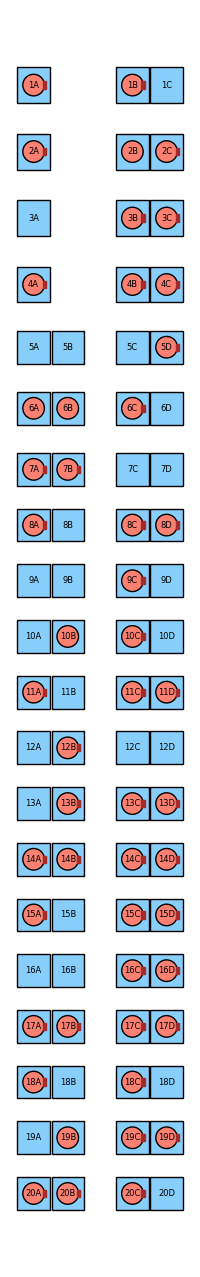

In [157]:
plane_boarding = PlaneBoarding(num_of_passengers, plane, boarding_choice, Passenger)
plane_boarding.animate()

In [ ]:
def run_simulation(boarding):
    steps = 0
    while not boarding.all_passengers_seated():
        boarding.step()
        steps += 1
    print(f"Plane was boarded in {steps} steps.")

In [ ]:
plane_boarding = PlaneBoarding(num_of_passengers, plane, boarding_choice, Passenger)
run_simulation(plane_boarding)